In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [2]:
#Filter for data analyst
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

#Drop NaN Values from the column for plotting
df_DA_US  = df_DA_US.dropna(subset=['salary_year_avg'])

In [4]:
df_DA_US['salary_year_avg'].sample(10)

122463     86000.000
542035     75000.000
749077    100363.625
618472    113269.500
14306     132500.000
151601     90000.000
209885     50000.000
656338    100000.000
417921     74000.000
210138     80000.000
Name: salary_year_avg, dtype: float64

<Axes: >

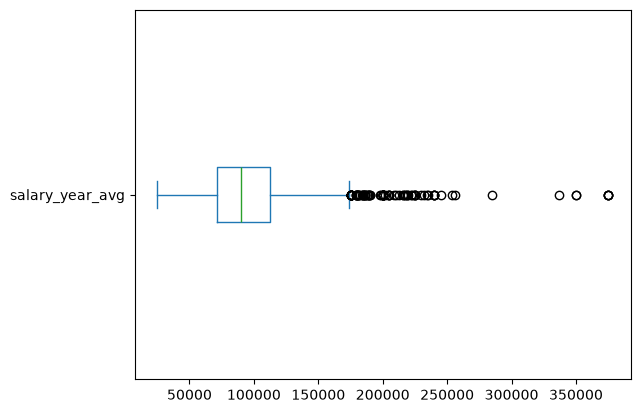

In [9]:
df_DA_US['salary_year_avg'].plot(kind='box', vert=False) #Pandas method
#plt.boxplot(df_DA_US['salary_year_avg']) #Matplotlib method

C:\Users\Avrah\AppData\Local\Temp\ipykernel_16572\2824838362.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list,tick_labels=job_titles,vert=False)


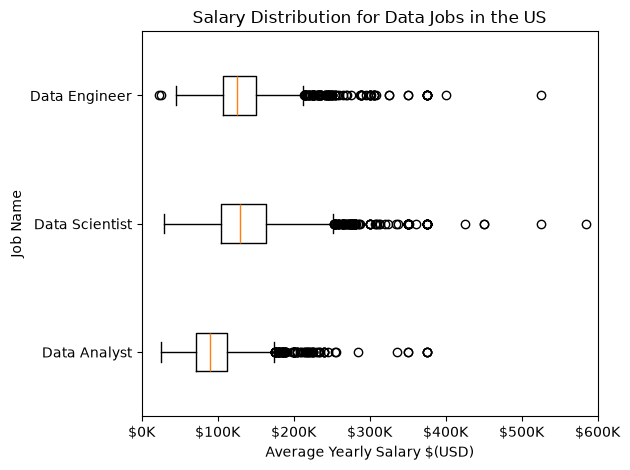

In [36]:
#Create a list of desired job titles
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

#Filter for desired job titles and only in the US.
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

#We want to create a *LIST* of the average yearly salary for the given filters.
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list,tick_labels=job_titles,vert=False)
plt.title('Salary Distribution for Data Jobs in the US')
plt.xlabel('Average Yearly Salary $(USD)')
plt.ylabel('Job Name')
plt.xlim(0,600000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

In [14]:
df_US['job_title_short'].value_counts()

job_title_short
Data Analyst      67816
Data Scientist    58830
Data Engineer     35080
Name: count, dtype: int64

In [18]:
job_list[0]

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64